In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

from utils import process_remote, process_insitu, fuse_datasets
from config import no_outlier_check, remote_features, insitu_features1, insitu_features2

In [3]:
def calculate_water_storage_change(
        df: pd.DataFrame,
        SWC: str,
        WTD: str,
        drainable_porosity: float = 0.25
) -> pd.DataFrame:
    """
    Calculates the daily change in water storage for a soil profile.
    """
    result_df = df.copy()

    result_df['delta_SWC'] = result_df[SWC].diff()
    result_df['delta_WTD'] = result_df[WTD].diff()

    result_df['delta_S_SWC'] = (result_df['delta_SWC'] * result_df[WTD])
    result_df['delta_S_WTD'] = (result_df['delta_WTD'] * drainable_porosity)

    result_df['delta_S'] = result_df['delta_S_SWC'] + result_df['delta_S_WTD']
    
    return result_df


In [4]:
# North
remote_df1 = process_remote(
    filepath='../data/processed/satellites/SDH1_S2_20m_2023-10_2026-06.csv',
    duplicates=True,
    reindex=True,
    outliers=True,
    interpolation=True,
    stats=True,
    smooth=True,
    window_length=14
)
insitu_df1 = process_insitu(
    filepath='../data/processed/in-situ/SDH1_daily-insitu-data.csv',
    duplicates=True,
    reindex=True,
    outliers=True,
    ignore_vars=no_outlier_check,
    interpolation=False,
    smooth=False
)
fused_df1 = fuse_datasets(
    insitu=insitu_df1,
    remote=remote_df1,
    startDate='2024-05-01',
    endDate='2026-05-01',
    features=remote_features+insitu_features1
)
z_df1 = fused_df1.apply(zscore, nan_policy='omit')

# South
remote_df2 = process_remote(
    filepath='../data/processed/satellites/SDH2_S2_20m_2023-10_2026-06.csv',
    duplicates=True,
    reindex=True,
    outliers=True,
    interpolation=True,
    stats=True,
    smooth=False,
    window_length=14
)
insitu_df2 = process_insitu(
    filepath='../data/processed/in-situ/SDH2_daily-insitu-data.csv',
    duplicates=True,
    reindex=True,
    outliers=True,
    ignore_vars=no_outlier_check,
    interpolation=True,
    smooth=False
)
fused_df2 = fuse_datasets(
    insitu=insitu_df2,
    remote=remote_df2,
    startDate='2024-05-01',
    endDate='2026-05-01',
    features=remote_features+insitu_features2
)
z_df2 = fused_df2.apply(zscore, nan_policy='omit')


/Users/pibonacic/Documents/projects/groundwater-remote-sensing/code/preparation.py:112: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = zscore(df_copy[cols_to_check], nan_policy='omit')


In [5]:
deltas1 = calculate_water_storage_change(fused_df1,
                                        'TEROS12-15cm_water-content_m3m3',
                                        'SDH1PS01_gw-depth_m',
                                        0.25)
z_deltas1 = deltas1.apply(zscore, nan_policy='omit')

deltas2 = calculate_water_storage_change(fused_df2,
                                        'TEROS12-18cm_water-content_m3m3',
                                        'SDH2PP01_gw-depth_m',
                                        0.25)
z_deltas2 = deltas2.apply(zscore, nan_policy='omit')

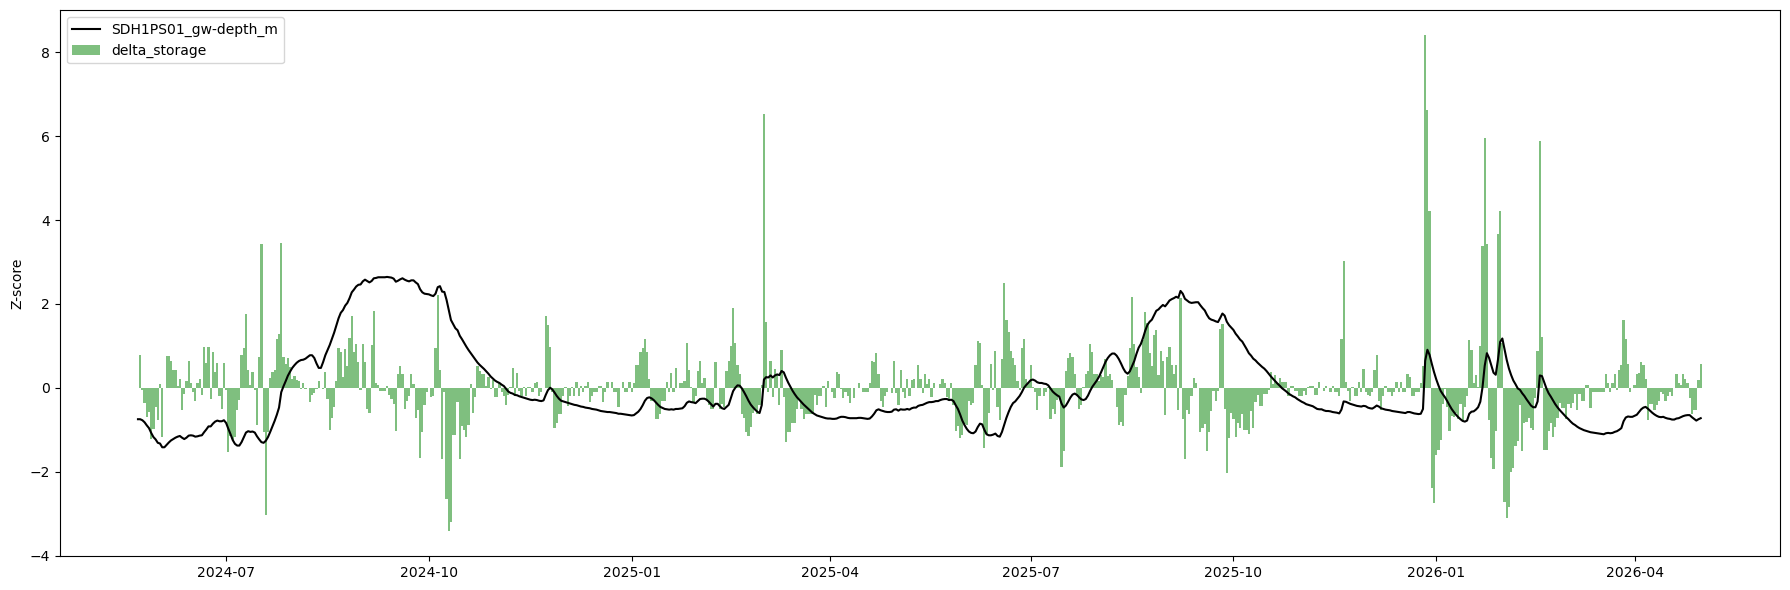

In [6]:
fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.plot(z_deltas1.index, z_deltas1['SDH1PS01_gw-depth_m'], label='SDH1PS01_gw-depth_m', c='k')
ax1.bar(z_deltas1.index, z_deltas1['delta_S'], label='delta_storage', alpha=0.5, color='green', width=1)
#ax1.bar(z_deltas1.index, z_deltas1['delta_S_SWC'], label='delta_S_SWC', alpha=0.5, width=1)
#ax1.bar(z_deltas1.index, z_deltas1['delta_S_WTD'], label='delta_S_WTD', alpha=0.5, width=1)

ax1.set_ylabel('Z-score')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

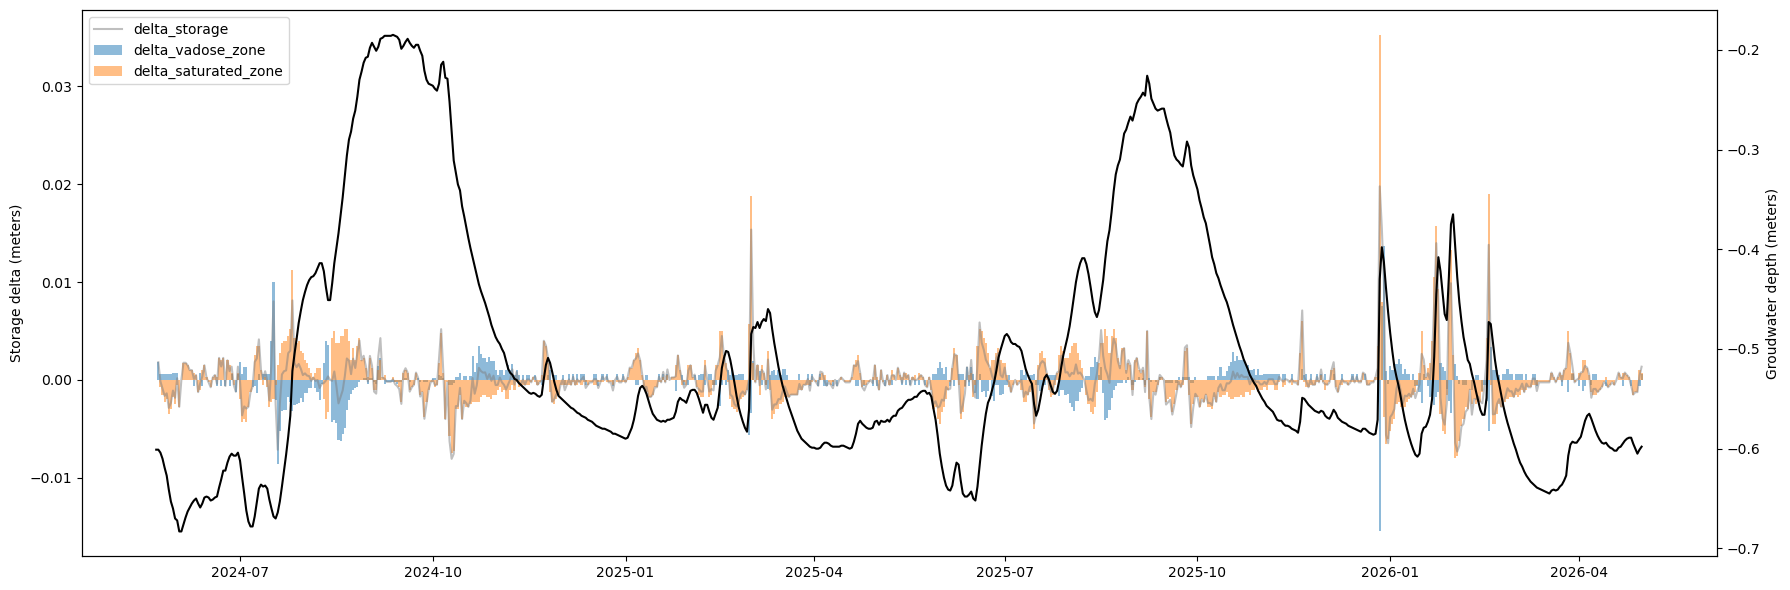

In [14]:
fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.plot(deltas1.index, deltas1['delta_S'], label='delta_storage', alpha=0.5, color='gray')
ax1.bar(deltas1.index, deltas1['delta_S_SWC'], label='delta_vadose_zone', alpha=0.5, width=1)
ax1.bar(deltas1.index, deltas1['delta_S_WTD'], label='delta_saturated_zone', alpha=0.5, width=1)

ax2 = ax1.twinx()
ax2.plot(deltas1.index, deltas1['SDH1PS01_gw-depth_m'], label='SDH1PS01_gw-depth_m', c='k')

ax1.set_ylabel('Storage delta (meters)')
ax2.set_ylabel('Groudwater depth (meters)')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

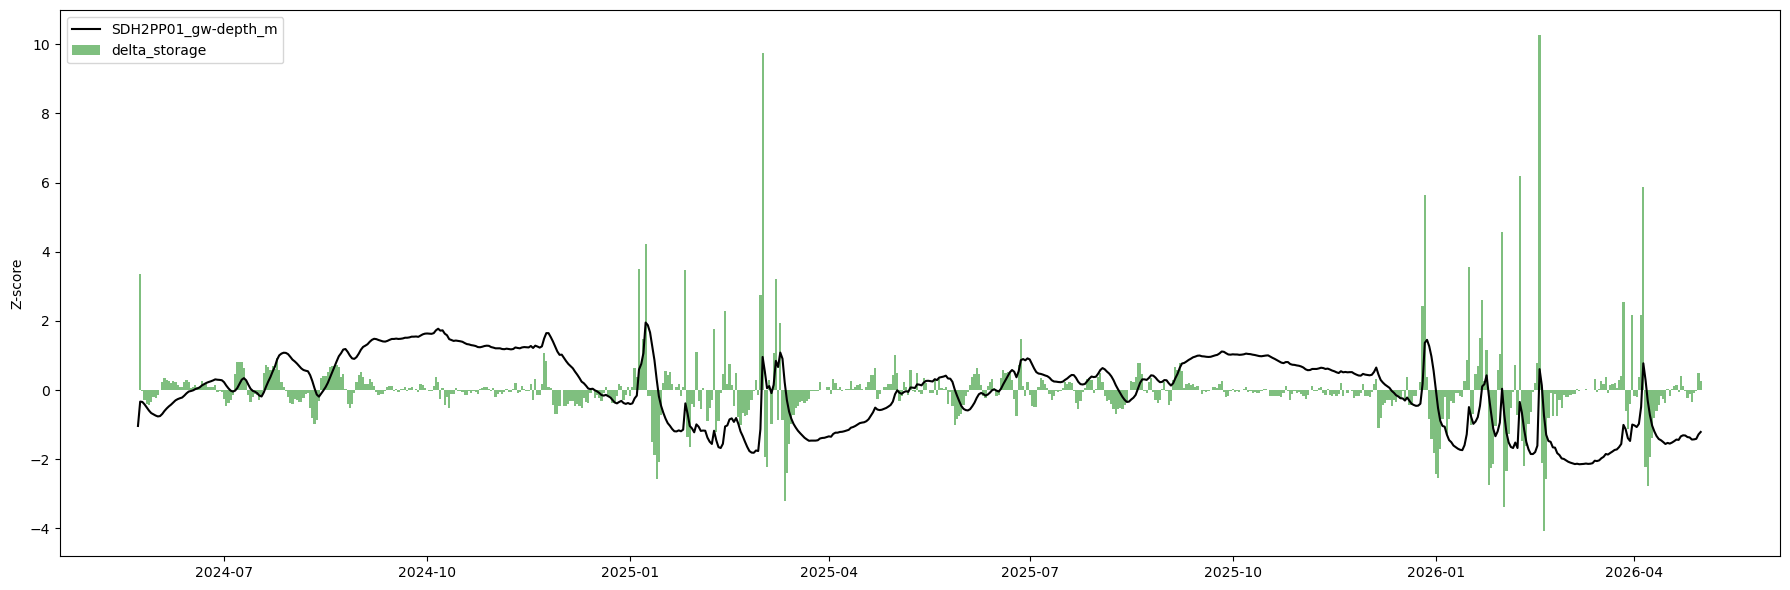

In [8]:
fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.plot(z_deltas2.index, z_deltas2['SDH2PP01_gw-depth_m'], label='SDH2PP01_gw-depth_m', c='k')
ax1.bar(z_deltas2.index, z_deltas2['delta_S'], label='delta_storage', alpha=0.5, color='green', width=1)
#ax1.bar(z_deltas2.index, z_deltas2['delta_S_SWC'], label='delta_S_SWC', alpha=0.5, width=1)
#ax1.bar(z_deltas2.index, z_deltas2['delta_S_WTD'], label='delta_S_WTD', alpha=0.5, width=1)

ax1.set_ylabel('Z-score')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

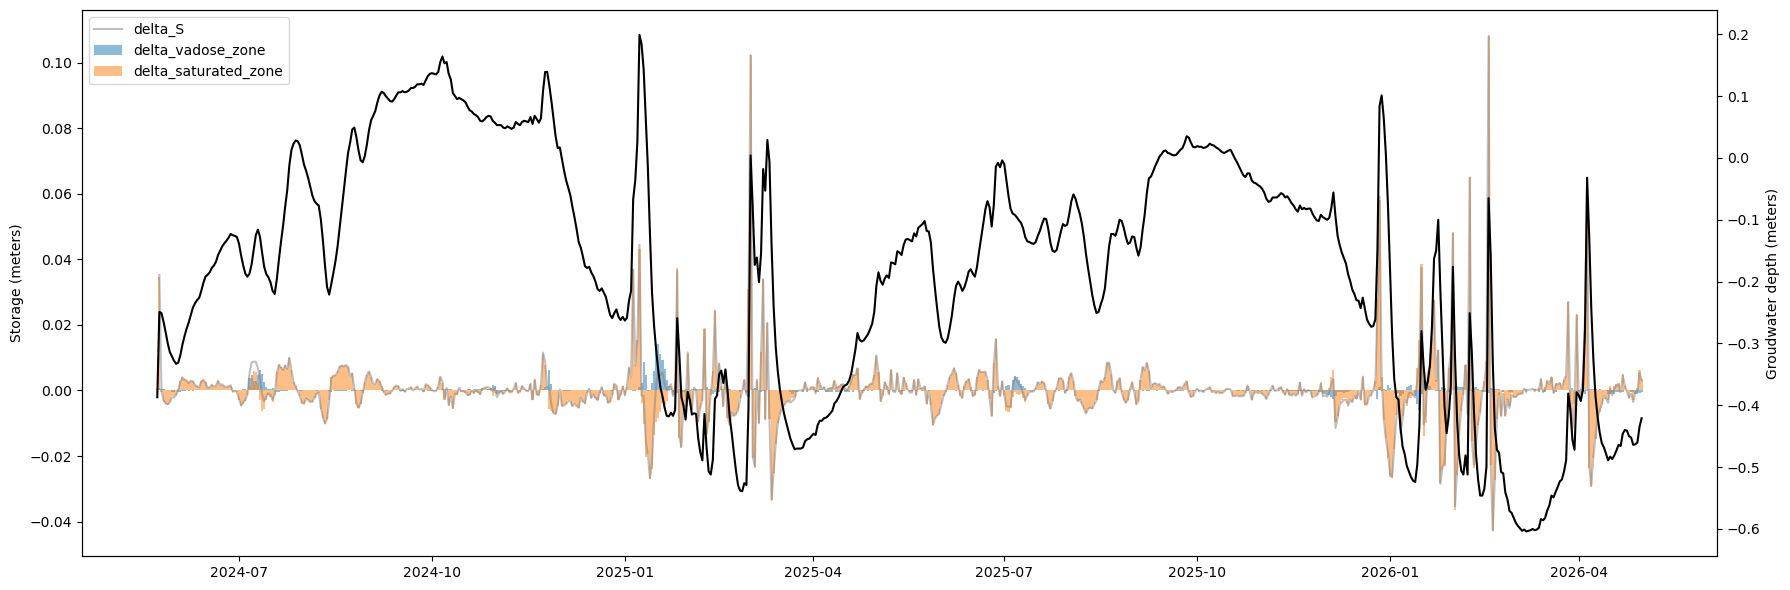

In [12]:
fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.plot(deltas2.index, deltas2['delta_S'], label='delta_S', alpha=0.5, color='gray')
ax1.bar(deltas2.index, deltas2['delta_S_SWC'], label='delta_vadose_zone', alpha=0.5, width=1)
ax1.bar(deltas2.index, deltas2['delta_S_WTD'], label='delta_saturated_zone', alpha=0.5, width=1)

ax2 = ax1.twinx()
ax2.plot(deltas2.index, deltas2['SDH2PP01_gw-depth_m'], label='SDH2PP01_gw-depth_m', c='black')

ax1.set_ylabel('Storage (meters)')
ax2.set_ylabel('Groudwater depth (meters)')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

Esto asume que el sensor a 18 cm está en la zona vadosa, pero bien podría ser que está semi-saturado, porque no tiene muchas variaciones durante el año. Solamnete se va a pique durante el invierno (congelamiento?).

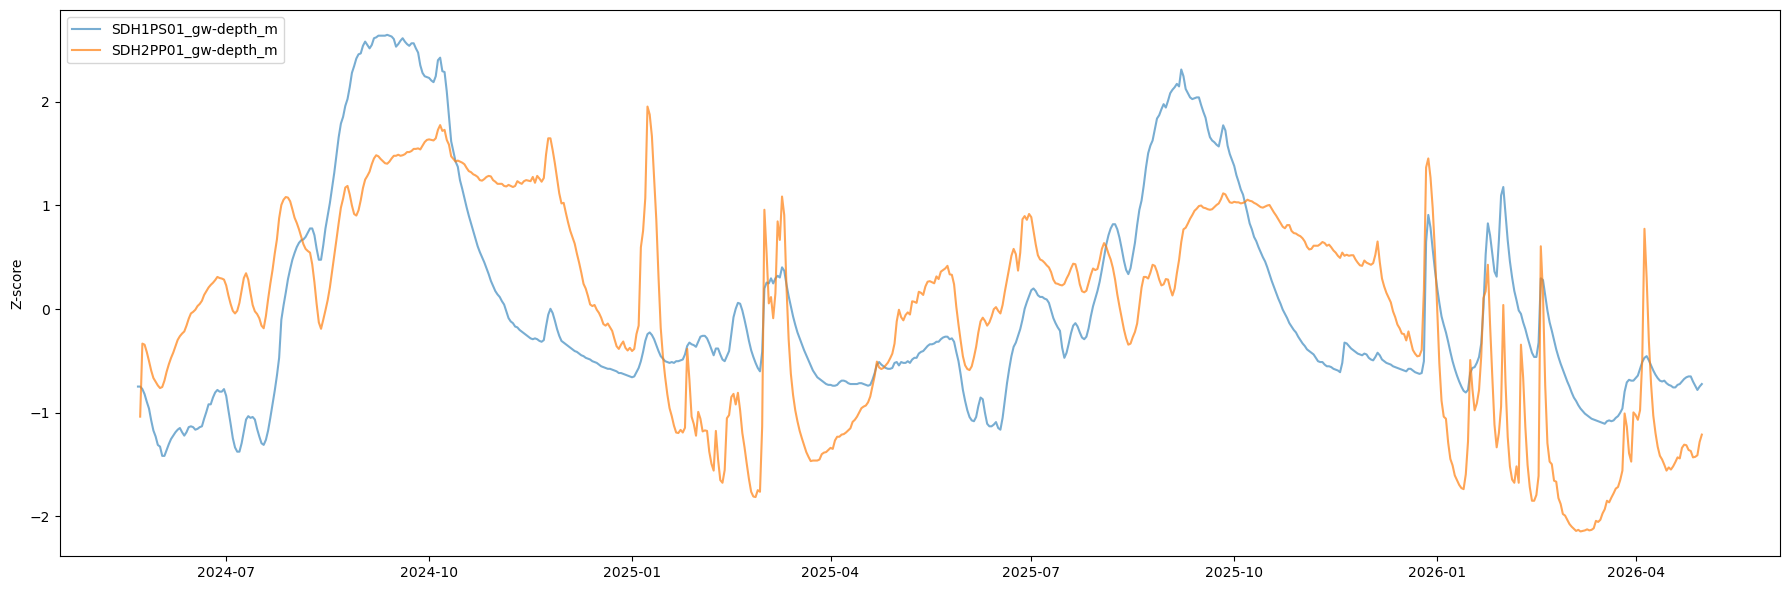

In [20]:
fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.plot(z_deltas1.index, z_deltas1['SDH1PS01_gw-depth_m'], label='SDH1PS01_gw-depth_m', alpha=0.6)
ax1.plot(z_deltas2.index, z_deltas2['SDH2PP01_gw-depth_m'], label='SDH2PP01_gw-depth_m', alpha=0.7)

ax1.set_ylabel('Z-score')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

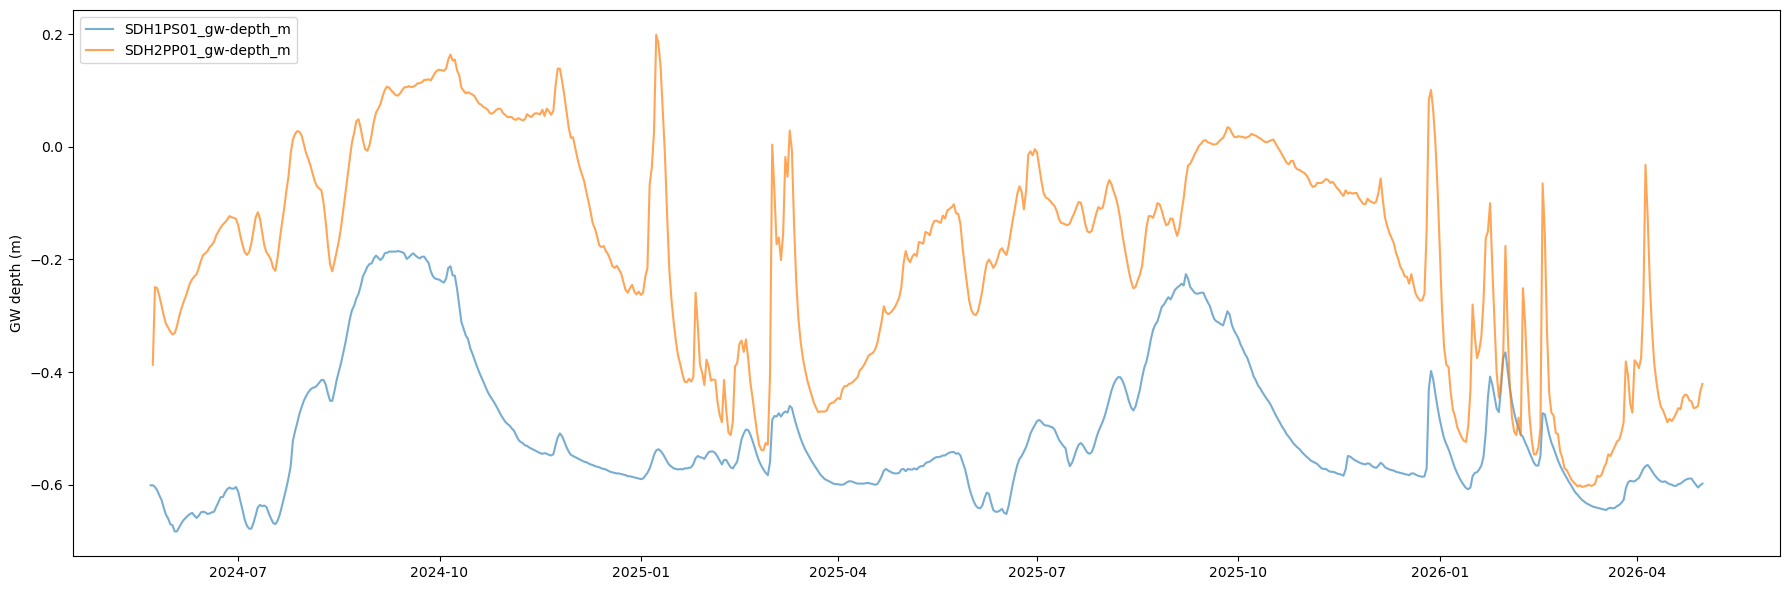

In [21]:
fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.plot(deltas1.index, deltas1['SDH1PS01_gw-depth_m'], label='SDH1PS01_gw-depth_m', alpha=0.6)
ax1.plot(deltas2.index, deltas2['SDH2PP01_gw-depth_m'], label='SDH2PP01_gw-depth_m', alpha=0.7)

ax1.set_ylabel('GW depth (m)')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()